# Time Series Preparation for Demand Forecasting

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

#### Load dataset

In [4]:
df = pd.read_csv("../data/cleaned/cleaned_retail.csv")

#### Preprocessing

In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

#### Daily Sales Aggregation

In [6]:
sales = (
    df.groupby("InvoiceDate")["TotalPrice"]
    .sum()
    .reset_index()
)

sales.columns = ["ds", "y"]

sales.head()

,ds,y
0,2010-12-01 08:26:00,139.12
1,2010-12-01 08:28:00,22.20
2,2010-12-01 08:34:00,348.78
3,2010-12-01 08:35:00,17.85
4,2010-12-01 08:45:00,855.86


#### Basic Dataset Check

In [7]:
print("Shape:", sales.shape)

sales.info()

Shape: (17282, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17282 entries, 0 to 17281
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      17282 non-null  datetime64[ns]
 1   y       17282 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 270.2 KB


#### Time Series Visualization

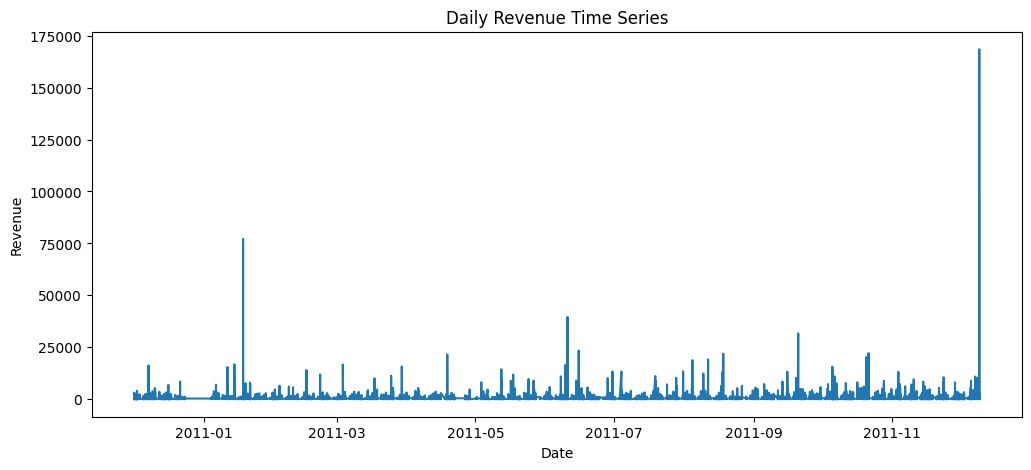

In [8]:
plt.figure(figsize=(12,5))

plt.plot(sales["ds"], sales["y"])

plt.title("Daily Revenue Time Series")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

#### Stationarity Test

In [9]:
result = adfuller(sales["y"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -128.862128115338
p-value: 0.0
Critical Values:
1%: -3.430728466039107
5%: -2.8617072672381836
10%: -2.566859032032201


In [10]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

The time series is stationary.


#### Time Series Decomposition

In [11]:
sales_ts = sales.set_index("ds")

decomposition = seasonal_decompose(
    sales_ts["y"],
    model="additive",
    period=30
)

#### Plot Decomposition

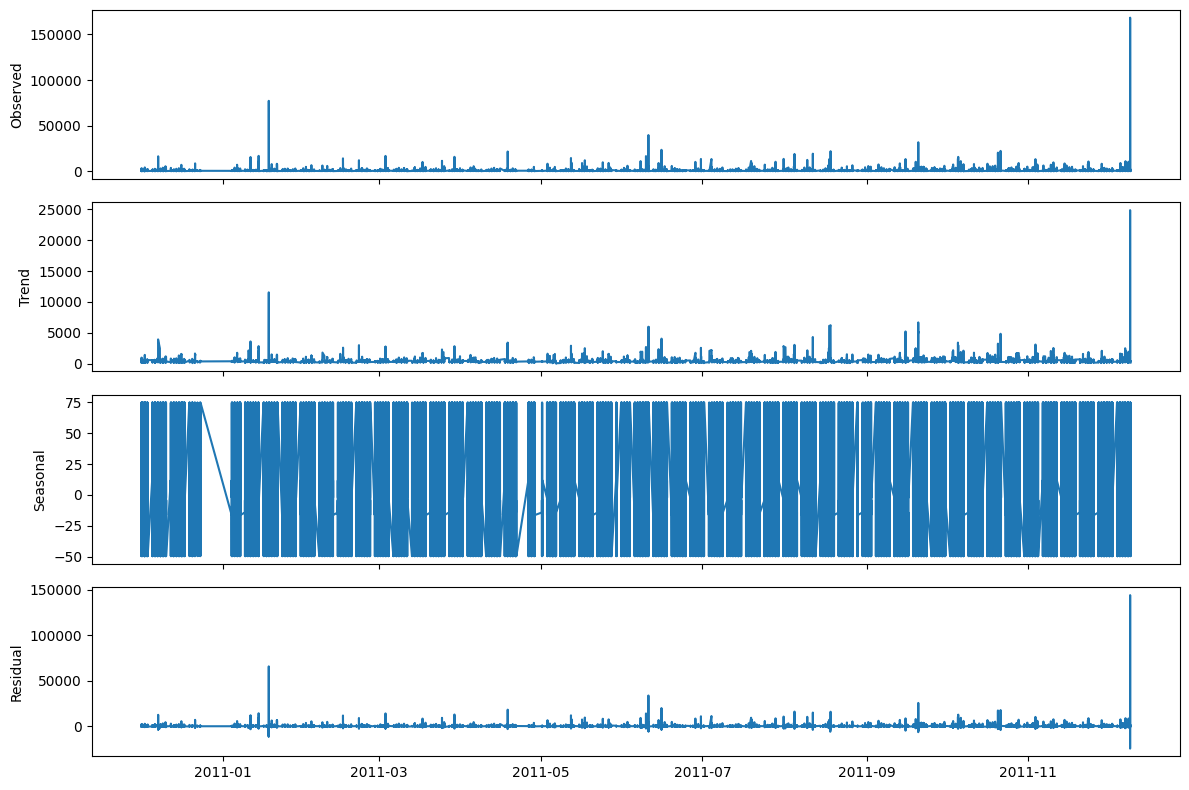

In [17]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axes[0].plot(decomposition.observed)
axes[0].set_ylabel("Observed")

axes[1].plot(decomposition.trend)
axes[1].set_ylabel("Trend")

axes[2].plot(decomposition.seasonal)
axes[2].set_ylabel("Seasonal")

axes[3].plot(decomposition.resid)
axes[3].set_ylabel("Residual")

plt.tight_layout()
plt.show()

#### ADF Test Results

The Augmented Dickey-Fuller (ADF) test produced an ADF statistic of -128.86 and a p-value of 0.0.

Since the p-value is less than 0.05, the null hypothesis of non-stationarity is rejected. This indicates that the sales time series is stationary and suitable for forecasting analysis.

#### Save Prepared Time Series

In [14]:
sales.to_csv(
    "../data/cleaned/time_series_data.csv",
    index=False
)